In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# load sheet data
df_drill = pd.read_excel("pp_evaluation.xlsx", sheet_name="drill")
df_mug = pd.read_excel("pp_evaluation.xlsx", sheet_name="mug")
df_dumbbell = pd.read_excel("pp_evaluation.xlsx", sheet_name="dumbbell")

df_drill.head()

,seed,ppo_sr,ppo_l2,ppo_avg_reward,ppo_avg_steps,moe_sr,moe_l2,moe_avg_reward,moe_avg_steps
0,42,76.36,14.4,3888.44,154.73,83.29,9.2,3784.40,134.57
1,7,77.40,14.1,4009.03,151.67,84.19,9.1,3813.16,131.90
2,123,78.69,14.4,4073.21,150.68,83.77,9.3,3732.15,133.14
3,2021,76.11,14.2,3814.69,154.11,85.77,9.4,3864.15,130.75
4,0,77.12,14.4,3969.78,152.41,83.32,9.2,3893.63,133.37


In [3]:
# Publication-quality plot settings
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.5,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.3,
})


# Kelly's colors of maximum contrast — maximally distinct 6 colors
COLORS = [
    '#4363D8',  # Blue
    '#3CB44B',  # Green
    '#E6194B',  # Red
    '#42D4F4',  # Cyan
    '#F58231',  # Orange
    '#911EB4',  # Purple
    '#FFD700',  # Gold
]

In [4]:
def calc_mean_std(df):
    """Calculate mean and std of the specified metric."""

    ppo_sr_mean = df['ppo_sr'].mean()
    ppo_sr_std = df['ppo_sr'].std()
    ppo_l2_mean = df['ppo_l2'].mean()
    ppo_l2_std = df['ppo_l2'].std()
    ppo_reward_mean = df['ppo_avg_reward'].mean()
    ppo_reward_std = df['ppo_avg_reward'].std()
    ppo_step_mean = df['ppo_avg_steps'].mean()
    ppo_step_std = df['ppo_avg_steps'].std()
    
    ppo = {
        'ppo_sr': (ppo_sr_mean, ppo_sr_std),
        'ppo_l2': (ppo_l2_mean, ppo_l2_std),
        'ppo_avg_reward': (ppo_reward_mean, ppo_reward_std),
        'ppo_avg_steps': (ppo_step_mean, ppo_step_std)
    }

    moe_sr_mean = df['moe_sr'].mean()
    moe_sr_std = df['moe_sr'].std()
    moe_l2_mean = df['moe_l2'].mean()
    moe_l2_std = df['moe_l2'].std()
    moe_reward_mean = df['moe_avg_reward'].mean()
    moe_reward_std = df['moe_avg_reward'].std()
    moe_step_mean = df['moe_avg_steps'].mean()
    moe_step_std = df['moe_avg_steps'].std()

    moe = {
        'moe_sr': (moe_sr_mean, moe_sr_std),
        'moe_l2': (moe_l2_mean, moe_l2_std),
        'moe_avg_reward': (moe_reward_mean, moe_reward_std),
        'moe_avg_steps': (moe_step_mean, moe_step_std)
    }

    print("=== Evaluation Results ===")
    print(f"PPO Success Rate: {ppo_sr_mean:.2f} ± {ppo_sr_std:.2f}")
    print(f"PPO L2 Distance: {ppo_l2_mean:.4f} ± {ppo_l2_std:.4f}")
    print(f"PPO Average Reward: {ppo_reward_mean:.2f} ± {ppo_reward_std:.2f}")
    print(f"PPO Average Steps: {ppo_step_mean:.2f} ± {ppo_step_std:.2f}")
    print("--------------------------")
    print(f"MOE Success Rate: {moe_sr_mean:.2f} ± {moe_sr_std:.2f}")
    print(f"MOE L2 Distance: {moe_l2_mean:.4f} ± {moe_l2_std:.4f}")
    print(f"MOE Average Reward: {moe_reward_mean:.2f} ± {moe_reward_std:.2f}")
    print(f"MOE Average Steps: {moe_step_mean:.2f} ± {moe_step_std:.2f}")
    print("==========================\n")

    return ppo, moe

drill_ppo, drill_moe = calc_mean_std(df_drill)
mug_ppo, mug_moe = calc_mean_std(df_mug)
dumbbell_ppo, dumbbell_moe = calc_mean_std(df_dumbbell)

=== Evaluation Results ===
PPO Success Rate: 76.96 ± 0.89
PPO L2 Distance: 14.3143 ± 0.1464
PPO Average Reward: 3934.85 ± 88.51
PPO Average Steps: 152.71 ± 1.55
--------------------------
MOE Success Rate: 83.85 ± 0.92
MOE L2 Distance: 9.2571 ± 0.1512
MOE Average Reward: 3824.41 ± 54.00
MOE Average Steps: 133.26 ± 1.49

=== Evaluation Results ===
PPO Success Rate: 92.43 ± 0.55
PPO L2 Distance: 18.7000 ± 0.1633
PPO Average Reward: 1639.22 ± 9.84
PPO Average Steps: 140.24 ± 0.85
--------------------------
MOE Success Rate: 95.45 ± 0.44
MOE L2 Distance: 17.4571 ± 0.1512
MOE Average Reward: 1707.25 ± 15.61
MOE Average Steps: 129.46 ± 0.85

=== Evaluation Results ===
PPO Success Rate: 65.65 ± 0.65
PPO L2 Distance: 10.9571 ± 0.1272
PPO Average Reward: 6362.23 ± 78.42
PPO Average Steps: 152.17 ± 0.81
--------------------------
MOE Success Rate: 96.40 ± 0.67
MOE L2 Distance: 11.6286 ± 0.1604
MOE Average Reward: 3495.83 ± 84.19
MOE Average Steps: 121.39 ± 2.18



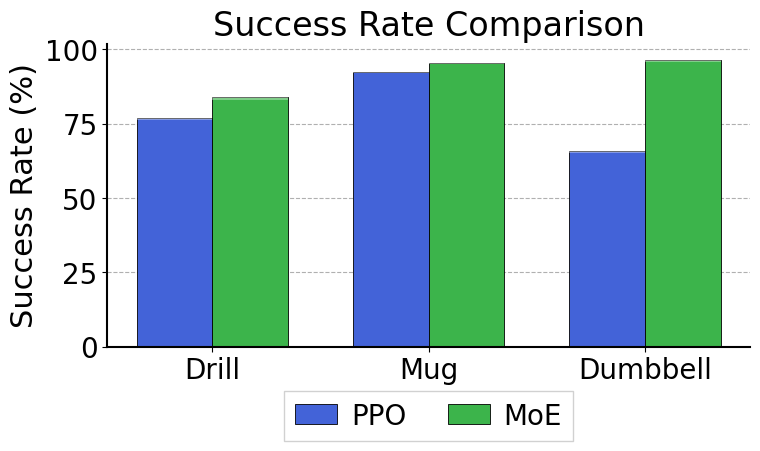

In [5]:
objects = ["Drill", "Mug", "Dumbbell"]
ppo_sr_means = [drill_ppo['ppo_sr'][0], mug_ppo['ppo_sr'][0], dumbbell_ppo['ppo_sr'][0]]
ppo_sr_stds  = [drill_ppo['ppo_sr'][1], mug_ppo['ppo_sr'][1], dumbbell_ppo['ppo_sr'][1]]
moe_sr_means = [drill_moe['moe_sr'][0], mug_moe['moe_sr'][0], dumbbell_moe['moe_sr'][0]]
moe_sr_stds  = [drill_moe['moe_sr'][1], mug_moe['moe_sr'][1], dumbbell_moe['moe_sr'][1]]

x = np.arange(len(objects))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))  # two-column paper width

ax.bar(x - width / 2, ppo_sr_means, width,
       label='PPO', color=COLORS[0], edgecolor='black', linewidth=0.6)
ax.bar(x + width / 2, moe_sr_means, width,
       label='MoE', color=COLORS[1], edgecolor='black', linewidth=0.6)

# Transparent std overlay rectangles
for i, (mean, std) in enumerate(zip(ppo_sr_means, ppo_sr_stds)):
    ax.bar(x[i] - width / 2, 2 * std, width,
           bottom=mean - std, color='white', alpha=0.35, edgecolor='none', zorder=3)

for i, (mean, std) in enumerate(zip(moe_sr_means, moe_sr_stds)):
    ax.bar(x[i] + width / 2, 2 * std, width,
           bottom=mean - std, color='white', alpha=0.35, edgecolor='none', zorder=3)

ax.set_title("Success Rate Comparison")
ax.set_ylabel("Success Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(objects)
ax.grid(True, axis='y', alpha=1.0, linestyle='--')  # y-axis grid only
ax.set_axisbelow(True)  # grid behind bars

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
      ncol=2, frameon=True, fancybox=False, shadow=False, framealpha=0.9,
      columnspacing=1.5,
      handlelength=1.5,
      handletextpad=0.5,
      borderpad=0.4,
      labelspacing=0.3)
plt.tight_layout()
fig.savefig("figures/plot_success_rate.png", dpi=300, bbox_inches='tight', pad_inches=0.1)

plt.show()


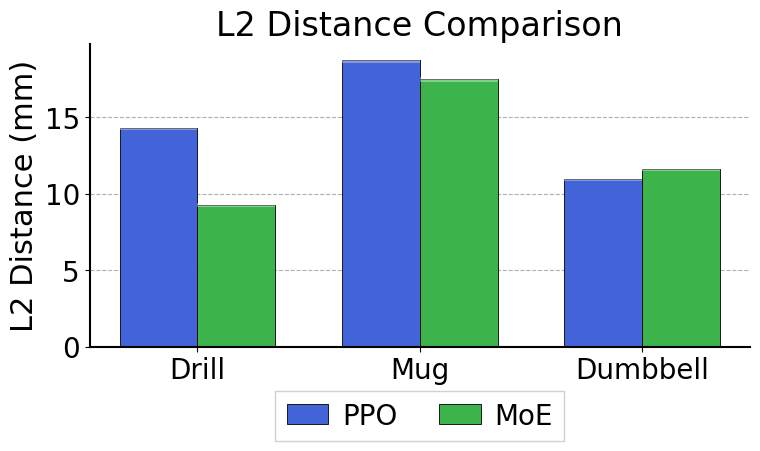

In [6]:
objects = ["Drill", "Mug", "Dumbbell"]
ppo_l2_means = [drill_ppo['ppo_l2'][0], mug_ppo['ppo_l2'][0], dumbbell_ppo['ppo_l2'][0]]
ppo_l2_stds  = [drill_ppo['ppo_l2'][1], mug_ppo['ppo_l2'][1], dumbbell_ppo['ppo_l2'][1]]
moe_l2_means = [drill_moe['moe_l2'][0], mug_moe['moe_l2'][0], dumbbell_moe['moe_l2'][0]]
moe_l2_stds  = [drill_moe['moe_l2'][1], mug_moe['moe_l2'][1], dumbbell_moe['moe_l2'][1]]

x = np.arange(len(objects))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width / 2, ppo_l2_means, width,
       label='PPO', color=COLORS[0], edgecolor='black', linewidth=0.6)
ax.bar(x + width / 2, moe_l2_means, width,
       label='MoE', color=COLORS[1], edgecolor='black', linewidth=0.6)

# Transparent std overlay rectangles
for i, (mean, std) in enumerate(zip(ppo_l2_means, ppo_l2_stds)):
    ax.bar(x[i] - width / 2, 2 * std, width,
           bottom=mean - std, color='white', alpha=0.35, edgecolor='none', zorder=3)

for i, (mean, std) in enumerate(zip(moe_l2_means, moe_l2_stds)):
    ax.bar(x[i] + width / 2, 2 * std, width,
           bottom=mean - std, color='white', alpha=0.35, edgecolor='none', zorder=3)

ax.set_title("L2 Distance Comparison")
ax.set_ylabel("L2 Distance (mm)")
ax.set_xticks(x)
ax.set_xticklabels(objects)
ax.grid(True, axis='y', alpha=1.0, linestyle='--')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
      ncol=2, frameon=True, fancybox=False, shadow=False, framealpha=0.9,
      columnspacing=1.5,
      handlelength=1.5,
      handletextpad=0.5,
      borderpad=0.4,
      labelspacing=0.3)
plt.tight_layout()
fig.savefig("figures/plot_l2_dist.png", dpi=300, bbox_inches='tight', pad_inches=0.1)

plt.show()
